bert_01_tokenize_embed.py
=========================
Stage 1 of the BERT-style masked attention walkthrough.

Pipeline:
    sentence
      → bert-base-uncased WordPiece tokenizer
      → add [CLS] and [SEP] special tokens
      → mask specific positions with [MASK]
      → token ids
      → token embedding lookup       (d_model-dim vectors)
      → token type embedding         (segment A vs B — always 0 here, single sentence)
      → learned positional embedding (BERT uses learned, not sinusoidal)
      → sum all three → final input representation
      → save to disk for script 02

BERT embedding differs from GPT in two ways:
  1. Three embeddings summed: token + position + token_type
  2. Positional encoding is LEARNED (nn.Embedding), not sinusoidal

Dependencies:
    pip install torch transformers matplotlib

In [1]:
cd "/content/drive/MyDrive/Courses/AI/masked_attention/bert"

/content/drive/MyDrive/Courses/AI/masked_attention/bert


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from transformers import BertTokenizer

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────

SENTENCE      = "the cat sat on the mat"
MODEL_ID      = "bert-base-uncased"
D_MODEL       = 64          # small for readability; real BERT uses 768
MAX_SEQ_LEN   = 512         # BERT's maximum; we only use T positions
SAVE_PT       = "bert_embeddings.pt"

# Which word positions (0-indexed in the original sentence words) to mask.
# "cat" is position 1, "mat" is position 5 — interesting because they rhyme
# and a trained BERT would use context to distinguish them.
MASK_WORDS    = [1, 5]      # "cat", "mat"

torch.manual_seed(0)

In [6]:
# ── 1. Tokenise ───────────────────────────────────────────────────────────────
#
# bert-base-uncased WordPiece tokenizer:
#   - lowercases everything
#   - splits unknown words into subword pieces  e.g. "sitting" → ["sit", "##ting"]
#   - automatically adds [CLS] at position 0 and [SEP] at the end
#
# encode_plus returns a dict with input_ids, token_type_ids, attention_mask

tokenizer = BertTokenizer.from_pretrained(MODEL_ID)

encoding = tokenizer(
    SENTENCE,
    add_special_tokens=True,
    return_tensors="pt",
)

token_ids       = encoding["input_ids"][0]          # (T,)
token_type_ids  = encoding["token_type_ids"][0]     # (T,)  all 0 for single sentence
tokens          = tokenizer.convert_ids_to_tokens(token_ids.tolist())
T               = len(token_ids)

print("=" * 60)
print("STEP 1 — TOKENISATION  (WordPiece + special tokens)")
print("=" * 60)
print(f"  Sentence       : '{SENTENCE}'")
print(f"  Tokens         : {tokens}")
print(f"  IDs            : {token_ids.tolist()}")
print(f"  Token types    : {token_type_ids.tolist()}  (all 0 = segment A)")
print(f"  Seq len T      : {T}  ([CLS] + {T-2} word tokens + [SEP])")
print(f"\n  Special token IDs:")
print(f"    [CLS]  = {tokenizer.cls_token_id}")
print(f"    [SEP]  = {tokenizer.sep_token_id}")
print(f"    [MASK] = {tokenizer.mask_token_id}")

VOCAB_SIZE = tokenizer.vocab_size   # 30 522 for bert-base-uncased
print(f"  Vocab size     : {VOCAB_SIZE}")

STEP 1 — TOKENISATION  (WordPiece + special tokens)
  Sentence       : 'the cat sat on the mat'
  Tokens         : ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']
  IDs            : [101, 1996, 4937, 2938, 2006, 1996, 13523, 102]
  Token types    : [0, 0, 0, 0, 0, 0, 0, 0]  (all 0 = segment A)
  Seq len T      : 8  ([CLS] + 6 word tokens + [SEP])

  Special token IDs:
    [CLS]  = 101
    [SEP]  = 102
    [MASK] = 103
  Vocab size     : 30522


In [7]:
# ── 2. Apply [MASK] tokens ────────────────────────────────────────────────────
#
# In real BERT training the 15% masking is random. Here we mask fixed positions
# for clarity. We store the original ids so we can compute loss against them.
#
# MASK_WORDS indexes into the *word* tokens (skipping [CLS] at position 0).
# Word token i lives at position i+1 in the full sequence.

original_ids = token_ids.clone()                    # (T,) — ground truth for loss
masked_ids   = token_ids.clone()                    # (T,) — model input

mask_positions = [w + 1 for w in MASK_WORDS]       # shift by 1 to skip [CLS]
for pos in mask_positions:
    masked_ids[pos] = tokenizer.mask_token_id

print("\n" + "=" * 60)
print("STEP 2 — MASKING")
print("=" * 60)
print(f"  Masking word positions {MASK_WORDS} → sequence positions {mask_positions}")
print(f"\n  Before masking: {tokens}")
masked_tokens = tokenizer.convert_ids_to_tokens(masked_ids.tolist())
print(f"  After masking : {masked_tokens}")
print(f"\n  original_ids  : {original_ids.tolist()}")
print(f"  masked_ids    : {masked_ids.tolist()}")
print(f"  (loss will only be computed at positions {mask_positions})")


STEP 2 — MASKING
  Masking word positions [1, 5] → sequence positions [2, 6]

  Before masking: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']
  After masking : ['[CLS]', 'the', '[MASK]', 'sat', 'on', 'the', '[MASK]', '[SEP]']

  original_ids  : [101, 1996, 4937, 2938, 2006, 1996, 13523, 102]
  masked_ids    : [101, 1996, 103, 2938, 2006, 1996, 103, 102]
  (loss will only be computed at positions [2, 6])


In [8]:
# ── 3. Three Embeddings ───────────────────────────────────────────────────────
#
# BERT input = token_emb + position_emb + token_type_emb
#
# token_emb     : maps token id      → d_model vector  (vocab × d_model)
# position_emb  : maps position 0..T → d_model vector  (max_seq_len × d_model)  LEARNED
# token_type_emb: maps segment id    → d_model vector  (2 × d_model)
#                 segment 0 = sentence A, segment 1 = sentence B (NSP task)
#                 for single-sentence input, all positions are segment 0

tok_emb_table      = nn.Embedding(VOCAB_SIZE,   D_MODEL)
pos_emb_table      = nn.Embedding(MAX_SEQ_LEN,  D_MODEL)   # learned, not sinusoidal
type_emb_table     = nn.Embedding(2,             D_MODEL)   # 2 segment types

positions          = torch.arange(T)                        # (T,)  0,1,...,T-1

tok_emb  = tok_emb_table(masked_ids)                        # (T, d_model)
pos_emb  = pos_emb_table(positions)                         # (T, d_model)
type_emb = type_emb_table(token_type_ids)                   # (T, d_model)

print("\n" + "=" * 60)
print("STEP 3 — THREE EMBEDDING TABLES")
print("=" * 60)
print(f"  tok_emb_table  : {tok_emb_table.weight.shape}  (vocab × d_model)")
print(f"  pos_emb_table  : {pos_emb_table.weight.shape}  (max_seq_len × d_model)  ← learned")
print(f"  type_emb_table : {type_emb_table.weight.shape}  (2 × d_model)")
print(f"\n  tok_emb        : {tok_emb.shape}")
print(f"  pos_emb        : {pos_emb.shape}")
print(f"  type_emb       : {type_emb.shape}")


STEP 3 — THREE EMBEDDING TABLES
  tok_emb_table  : torch.Size([30522, 64])  (vocab × d_model)
  pos_emb_table  : torch.Size([512, 64])  (max_seq_len × d_model)  ← learned
  type_emb_table : torch.Size([2, 64])  (2 × d_model)

  tok_emb        : torch.Size([8, 64])
  pos_emb        : torch.Size([8, 64])
  type_emb       : torch.Size([8, 64])


In [10]:
# ── 4. Sum → input representation ─────────────────────────────────────────────
#
# x[i] = tok_emb[i] + pos_emb[i] + type_emb[i]
# All three tables are learned jointly during pretraining.
# LayerNorm + dropout would follow in real BERT; omitted here for clarity.

x = tok_emb + pos_emb + type_emb                            # (T, d_model)

print("\n" + "=" * 60)
print("STEP 4 — SUM  x = tok_emb + pos_emb + type_emb")
print("=" * 60)
print(f"  x : {x.shape}  ← input to attention layer")
print(f"\n  x[0]  ([CLS])  = {x[0].detach().numpy().round(3)[:6]} ...")
print(f"  x[{mask_positions[0]}]  ([MASK]) = {x[mask_positions[0]].detach().numpy().round(3)[:6]} ...")


STEP 4 — SUM  x = tok_emb + pos_emb + type_emb
  x : torch.Size([8, 64])  ← input to attention layer

  x[0]  ([CLS])  = [-0.047 -0.833  1.958  1.325 -1.231  0.431] ...
  x[2]  ([MASK]) = [-0.682 -3.395  1.385  0.921 -1.516  0.827] ...


In [11]:
# ── 5. Save ───────────────────────────────────────────────────────────────────

payload = {
    "x":              x.detach(),
    "tok_emb":        tok_emb.detach(),
    "pos_emb":        pos_emb.detach(),
    "type_emb":       type_emb.detach(),
    "masked_ids":     masked_ids,
    "original_ids":   original_ids,
    "token_type_ids": token_type_ids,
    "tokens":         tokens,
    "masked_tokens":  masked_tokens,
    "mask_positions": mask_positions,
    "T":              T,
    "D_MODEL":        D_MODEL,
    "VOCAB_SIZE":     VOCAB_SIZE,
    "SENTENCE":       SENTENCE,
    "emb_weight":     tok_emb_table.weight.detach(),  # (vocab, d_model) for unembed
}
torch.save(payload, SAVE_PT)
print(f"\n  Saved → '{SAVE_PT}'")


  Saved → 'bert_embeddings.pt'


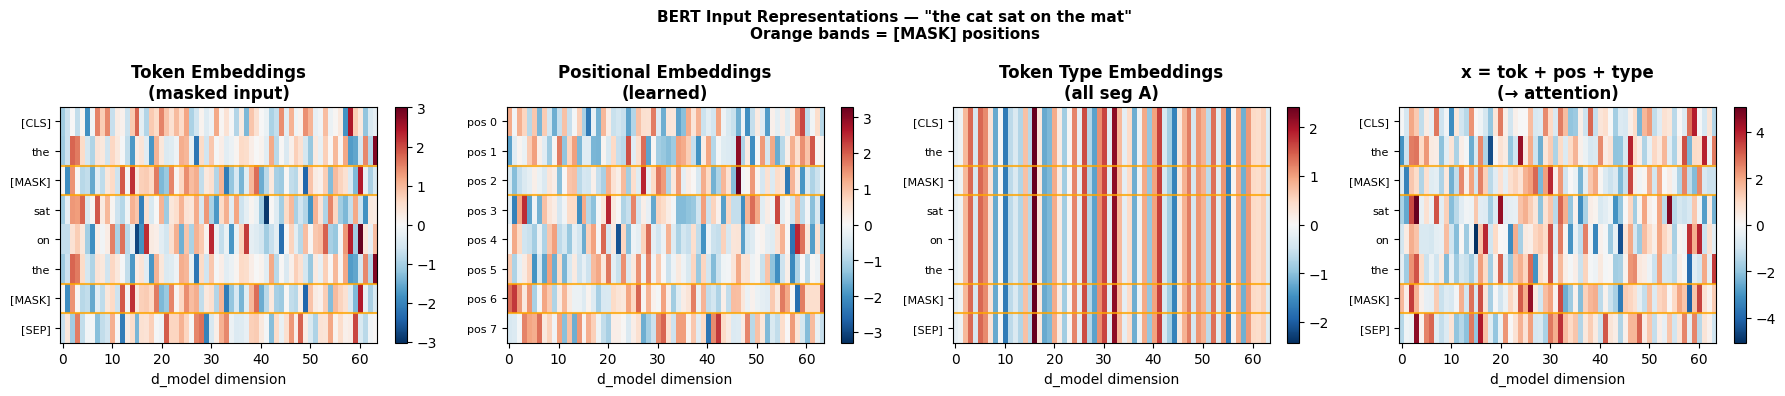

  Figure saved → 'bert_01_embeddings.png'


In [12]:
# ── 6. Visualise ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

def heatmap(ax, data, title, yticklabels=None):
    d = data.detach().numpy()
    im = ax.imshow(d, aspect="auto", cmap="RdBu_r",
                   vmin=-abs(d).max(), vmax=abs(d).max())
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("d_model dimension")
    if yticklabels:
        ax.set_yticks(range(len(yticklabels)))
        ax.set_yticklabels(yticklabels, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)

heatmap(axes[0], tok_emb,  "Token Embeddings\n(masked input)",  masked_tokens)
heatmap(axes[1], pos_emb,  "Positional Embeddings\n(learned)",
        [f"pos {i}" for i in range(T)])
heatmap(axes[2], type_emb, "Token Type Embeddings\n(all seg A)",  masked_tokens)
heatmap(axes[3], x,        "x = tok + pos + type\n(→ attention)", masked_tokens)

# highlight masked positions
for ax in axes:
    for pos in mask_positions:
        ax.axhline(pos - 0.5, color="orange", lw=1.5, alpha=0.8)
        ax.axhline(pos + 0.5, color="orange", lw=1.5, alpha=0.8)

plt.suptitle(
    f'BERT Input Representations — "{SENTENCE}"\n'
    f'Orange bands = [MASK] positions',
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("bert_01_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure saved → 'bert_01_embeddings.png'")